# Analyse a single SHARC trajectory

Set `TRAJECTORY_PATH` to the TRAJ_* folder, set (1-based) atomic indices, then Run All

In [26]:
# Input trajectory information

from pathlib import Path

TRAJECTORY_PATH = Path("../../sharc_molcas_scripts/output/ethene_molcas_ktdc/Singlet_1/TRAJ_00001")
MAXIMUM_TIME_FS = 200 # trajectory information after this time will be cut off
FILTER_SETTINGS_PATH = Path("../../../data_helpers/filtering/shnitsel_defaults.json")

BOND_LENGTH_INDICES = (1, 2)
DIHEDRAL_INDICES = (3, 1, 2, 4)

BONDS = [
    (1, 2),
    (1, 3),
    (1, 5),
    (2, 4),
    (2, 6)
]


In [27]:
# Imports and parse trajectory

import sys
import matplotlib.pyplot as plt

repository_path = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "data_helpers" / "filtering" / "filter_sharc_trajectory.py").is_file()
)
tools_path = repository_path / "sharc_scripts" / "tools"
filtering_path = repository_path / "data_helpers" / "filtering"
sys.path[:0] = [
    str(repository_path),
    str(tools_path),
    str(tools_path / "trajectory_tools"),
    str(filtering_path),
]

from parse_sharc_output import read_sharc_trajectory
from plot_hop_geoms import plot_hop_geoms
from plot_trajectory_2d import plot_trajectory_2d
from plot_trajectory_bond_lengths import plot_trajectory_bond_lengths
from filter_sharc_trajectory import filter_sharc_trajectory

trajectory = read_sharc_trajectory(
    TRAJECTORY_PATH,
    maximum_time_fs=MAXIMUM_TIME_FS,
)

if trajectory is None:
    raise RuntimeError(f"Could not read {TRAJECTORY_PATH}")

print(f"Trajectory: {trajectory.path.name}")
print(f"Frames: {len(trajectory.frames)}")
print(f"First time: {trajectory.frames[0].time_fs:.3f} fs")
print(f"Last time: {trajectory.frames[-1].time_fs:.3f} fs")
print("Observed states: " + ", ".join(
    f"S{state - 1}" for state in sorted({frame.state for frame in trajectory.frames})
))


Trajectory: TRAJ_00001
Frames: 401
First time: 0.000 fs
Last time: 200.000 fs
Observed states: S0, S1, S2


In [28]:
# Filter trajectory using SHNITSEL defaults

filter_result = filter_sharc_trajectory(
    trajectory,
    FILTER_SETTINGS_PATH,
    BONDS,
)

filtered_trajectory = filter_result["filtered_trajectory"]

if not filter_result["filtered"]:
    print("Trajectory passes all filters")
else:
    print(
        f"Trajectory fails at step {filter_result['step_number']}, "
        f"time {filter_result['time_fs']:.3f}fs due to:"
    )
    for failure in filter_result["failed_criteria"]:
        print(f"{failure['criterion']}: {failure['message']}")


Trajectory fails at step 4, time 2.000fs due to:
active_potential_step: Active potential energy step 0.713 eV exceeds 0.700 eV
kinetic_energy_step: Kinetic energy step 0.709 eV exceeds 0.700 eV


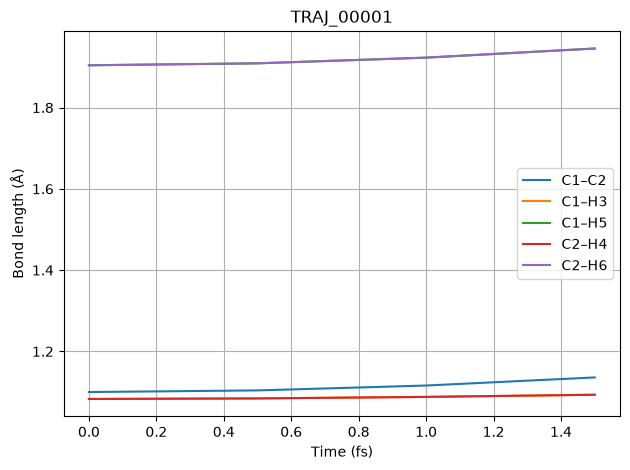

In [29]:
# Plot bond lengths against time

fig, ax = plot_trajectory_bond_lengths(
    filtered_trajectory,
    bonds=BONDS,
)
plt.show()


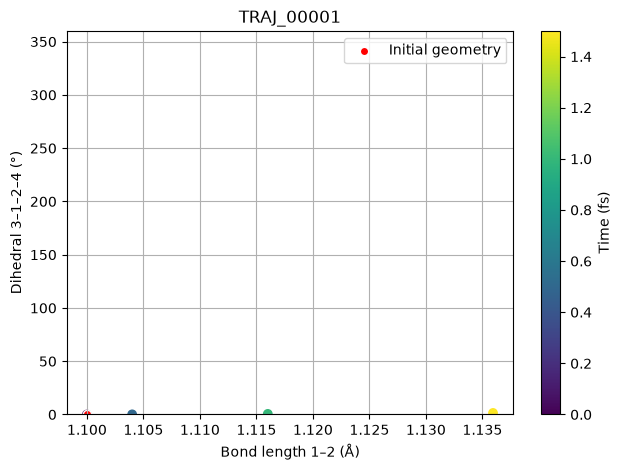

In [30]:
# Plot bond length against dihedral for the trajectory

fig, ax = plot_trajectory_2d(
    filtered_trajectory,
    bond_length_indices=BOND_LENGTH_INDICES,
    dihedral_indices=DIHEDRAL_INDICES,
)
ax.set_ylim(0, 360)
plt.show()


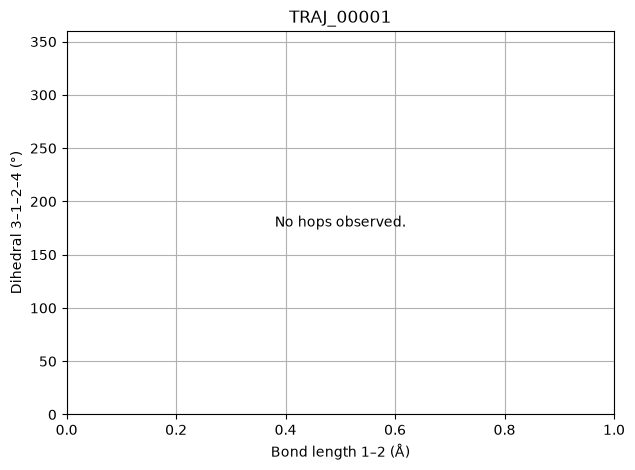

In [31]:
# Plot hop geometries

fig, ax = plot_hop_geoms(
    filtered_trajectory,
    bond_length_indices=BOND_LENGTH_INDICES,
    dihedral_indices=DIHEDRAL_INDICES,
)
ax.set_ylim(0, 360)
plt.show()
